# RetainIQ — Phase 8.2: Churn & Revenue Benchmarking

## Objective

I compare segments, states, and qualifying cities against explicit internal benchmark references. The main metrics are churn rate and historical revenue exposure, with CLTV included as a value context metric.

I report **benchmark gaps** rather than a subjective score. A positive churn gap means the observed churn rate is above the selected benchmark; a negative gap means it is below the benchmark.

### Notebook presentation rule

For every relevant analytical code cell, I place a **Result & conclusion** markdown cell immediately after it. Setup-only cells are not padded with artificial conclusions.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

ROOT = Path("..")
OUTPUT_DIR = ROOT / "outputs"
CONFIG_DIR = ROOT / "config"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def print_result(message):
    print(f"Result: {message}")


In [4]:
phase_07_dir = ROOT.resolve().parent / "Phase 7 — Retention Strategy & Business Intelligence Layer" / "outputs"

def load_base_csv(filename):
    local_path = OUTPUT_DIR / filename
    p7_path = phase_07_dir / filename
    if local_path.exists():
        return pd.read_csv(local_path)
    elif p7_path.exists():
        return pd.read_csv(p7_path)
    else:
        raise FileNotFoundError(
            f"Required input {filename} not found in {OUTPUT_DIR} or {phase_07_dir}. "
            "Please ensure Phase 7 and Notebook 8.1 have been run."
        )

segment_df = load_base_csv("phase_07_segment_business_base.csv")
state_df = load_base_csv("phase_07_state_business_base.csv")
city_df = load_base_csv("phase_07_city_business_base.csv")

benchmark_ref_path = OUTPUT_DIR / "benchmark_reference.csv"
if not benchmark_ref_path.exists():
    raise FileNotFoundError(
        f"Required benchmark reference not found: {benchmark_ref_path}. "
        "Please run Notebook 8.1 first to generate benchmark_reference.csv."
    )
benchmark_reference = pd.read_csv(benchmark_ref_path)

params = pd.read_csv(CONFIG_DIR / "benchmark_parameters.csv")
city_min = int(params.loc[params["parameter"] == "minimum_city_market_size", "value"].iloc[0])
tolerance_pp = float(params.loc[params["parameter"] == "benchmark_tolerance_pp", "value"].iloc[0])

portfolio_churn = float(benchmark_reference.loc[benchmark_reference["benchmark_name"] == "Portfolio weighted churn", "benchmark_value"].iloc[0])
portfolio_cltv = float(benchmark_reference.loc[benchmark_reference["benchmark_name"] == "Portfolio weighted CLTV", "benchmark_value"].iloc[0])
portfolio_risk_per_customer = float(benchmark_reference.loc[benchmark_reference["benchmark_name"] == "Portfolio revenue-at-risk per customer", "benchmark_value"].iloc[0])
peer_city_churn = float(benchmark_reference.loc[benchmark_reference["benchmark_name"] == "Median qualifying-city churn", "benchmark_value"].iloc[0])

for frame in [segment_df, state_df, city_df]:
    for col in ["customers", "churned_customers", "churn_rate_pct", "avg_cltv", "revenue_at_risk"]:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

print_result("Loaded the internal benchmark references and benchmark comparison inputs.")


Result: Loaded the internal benchmark references and benchmark comparison inputs.


### Result & conclusion

The benchmarking notebook is anchored to the exact reference values generated in 8.1. This prevents benchmark definitions from drifting between notebooks.

In [3]:
segment_benchmark = segment_df[[
    "segment_id", "segment_name", "retention_profile", "customers",
    "churned_customers", "churn_rate_pct", "avg_cltv", "revenue_at_risk"
]].copy()

segment_benchmark["revenue_at_risk_per_customer"] = np.where(
    segment_benchmark["customers"] > 0,
    segment_benchmark["revenue_at_risk"] / segment_benchmark["customers"],
    np.nan
)
segment_benchmark["churn_gap_pp"] = segment_benchmark["churn_rate_pct"] - portfolio_churn
segment_benchmark["cltv_gap_pct"] = np.where(
    portfolio_cltv != 0,
    (segment_benchmark["avg_cltv"] / portfolio_cltv - 1) * 100,
    np.nan
)
segment_benchmark["revenue_risk_per_customer_gap_pct"] = np.where(
    portfolio_risk_per_customer != 0,
    (segment_benchmark["revenue_at_risk_per_customer"] / portfolio_risk_per_customer - 1) * 100,
    np.nan
)
segment_benchmark["benchmark_status"] = np.select(
    [segment_benchmark["churn_gap_pp"] > tolerance_pp, segment_benchmark["churn_gap_pp"] < -tolerance_pp],
    ["Above benchmark", "Below benchmark"],
    default="Within benchmark"
)

segment_benchmark = segment_benchmark.sort_values("churn_gap_pp", ascending=False).reset_index(drop=True)
print_result(f"Benchmarked {len(segment_benchmark)} customer segments against the {portfolio_churn:.2f}% portfolio churn rate.")
display(segment_benchmark)

Result: Benchmarked 3 customer segments against the 26.54% portfolio churn rate.


,segment_id,segment_name,retention_profile,customers,churned_customers,churn_rate_pct,avg_cltv,revenue_at_risk,revenue_at_risk_per_customer,churn_gap_pp,cltv_gap_pct,revenue_risk_per_customer_gap_pct,benchmark_status
0,0,Segment 0 — Emerging Risk,Retention Priority,3226,1516,46.99,4013.45,1944581.19,602.784002,20.453013,-8.791358,15.224699,Above benchmark
1,2,Segment 2 — High-Value At-Risk,Protect High-Value,2260,243,10.75,4972.51,1696896.61,750.839208,-15.786987,13.003995,43.526074,Below benchmark
2,1,Segment 1 — High-Value Stable,Maintain Value,1557,110,7.06,4371.24,42982.02,27.605665,-19.476987,-0.660314,-94.723061,Below benchmark


### Result & conclusion

Each segment now has a transparent churn-rate gap and value/exposure context. The benchmark status uses only the explicit tolerance configured in Phase 8.

In [4]:
state_benchmark = state_df[[
    "state", "customers", "churned_customers", "churn_rate_pct",
    "avg_cltv", "revenue_at_risk"
]].copy()
state_benchmark["revenue_at_risk_per_customer"] = np.where(
    state_benchmark["customers"] > 0,
    state_benchmark["revenue_at_risk"] / state_benchmark["customers"],
    np.nan
)
state_benchmark["churn_gap_pp"] = state_benchmark["churn_rate_pct"] - portfolio_churn
state_benchmark["cltv_gap_pct"] = np.where(
    portfolio_cltv != 0,
    (state_benchmark["avg_cltv"] / portfolio_cltv - 1) * 100,
    np.nan
)
state_benchmark["revenue_risk_per_customer_gap_pct"] = np.where(
    portfolio_risk_per_customer != 0,
    (state_benchmark["revenue_at_risk_per_customer"] / portfolio_risk_per_customer - 1) * 100,
    np.nan
)
state_benchmark["benchmark_status"] = np.select(
    [state_benchmark["churn_gap_pp"] > tolerance_pp, state_benchmark["churn_gap_pp"] < -tolerance_pp],
    ["Above benchmark", "Below benchmark"],
    default="Within benchmark"
)
state_benchmark = state_benchmark.sort_values("churn_gap_pp", ascending=False).reset_index(drop=True)
print_result(f"Benchmarked {len(state_benchmark)} states against the {portfolio_churn:.2f}% portfolio churn rate.")
display(state_benchmark.head(25))

Result: Benchmarked 1 states against the 26.54% portfolio churn rate.


,state,customers,churned_customers,churn_rate_pct,avg_cltv,revenue_at_risk,revenue_at_risk_per_customer,churn_gap_pp,cltv_gap_pct,revenue_risk_per_customer_gap_pct,benchmark_status
0,California,7043,1869,26.54,4400.3,3684459.82,523.137842,0.003013,0.000097,-2.220446e-14,Within benchmark


### Result & conclusion

State-level benchmarking shows which states sit above, within, or below the portfolio churn reference while preserving customer volume and historical revenue exposure as context.

In [5]:
city_benchmark = city_df.copy()
city_benchmark["revenue_at_risk_per_customer"] = np.where(
    city_benchmark["customers"] > 0,
    city_benchmark["revenue_at_risk"] / city_benchmark["customers"],
    np.nan
)
city_benchmark = city_benchmark[city_benchmark["customers"] >= city_min].copy()
city_benchmark["churn_gap_to_portfolio_pp"] = city_benchmark["churn_rate_pct"] - portfolio_churn
city_benchmark["churn_gap_to_peer_city_pp"] = city_benchmark["churn_rate_pct"] - peer_city_churn
city_benchmark["cltv_gap_pct"] = np.where(
    portfolio_cltv != 0,
    (city_benchmark["avg_cltv"] / portfolio_cltv - 1) * 100,
    np.nan
)
city_benchmark["revenue_risk_per_customer_gap_pct"] = np.where(
    portfolio_risk_per_customer != 0,
    (city_benchmark["revenue_at_risk_per_customer"] / portfolio_risk_per_customer - 1) * 100,
    np.nan
)
city_benchmark["benchmark_status"] = np.select(
    [city_benchmark["churn_gap_to_peer_city_pp"] > tolerance_pp, city_benchmark["churn_gap_to_peer_city_pp"] < -tolerance_pp],
    ["Above peer benchmark", "Below peer benchmark"],
    default="Within peer benchmark"
)
city_benchmark = city_benchmark.sort_values("churn_gap_to_peer_city_pp", ascending=False).reset_index(drop=True)
print_result(f"Benchmarked {len(city_benchmark)} qualifying cities against the {peer_city_churn:.2f}% peer-city churn median.")
display(city_benchmark.head(30))

Result: Benchmarked 27 qualifying cities against the 26.62% peer-city churn median.


,state,city,customers,churned_customers,avg_cltv,total_revenue,avg_monthly_charge,avg_satisfaction,churn_rate_pct,revenue_at_risk,revenue_at_risk_per_customer,churn_gap_to_portfolio_pp,churn_gap_to_peer_city_pp,cltv_gap_pct,revenue_risk_per_customer_gap_pct,benchmark_status
0,California,San Diego,285,185,4345.09,738416.01,72.02,2.54,64.91,385446.39,1352.443474,38.373013,38.29,-1.254592,158.525262,Above peer benchmark
1,California,Fallbrook,43,26,4531.28,93409.28,69.83,2.72,60.47,34691.78,806.785581,33.933013,33.85,2.976715,54.220459,Above peer benchmark
2,California,Temecula,38,22,4367.87,119268.27,76.28,2.53,57.89,44102.41,1160.589737,31.353013,31.27,-0.736899,121.851612,Above peer benchmark
3,California,Modesto,28,12,4364.64,65847.36,69.56,2.86,42.86,11909.92,425.354286,16.323013,16.24,-0.810304,-18.691738,Above peer benchmark
4,California,Santa Barbara,28,10,4198.11,78526.26,62.84,3.21,35.71,46033.71,1644.061071,9.173013,9.09,-4.594822,214.269193,Above peer benchmark
5,California,Glendale,40,13,4355.95,90777.55,58.42,3.12,32.50,10622.55,265.563750,5.963013,5.88,-1.007790,-49.236372,Above peer benchmark
6,California,Torrance,25,8,4606.20,77995.90,61.58,2.88,32.00,33534.79,1341.391600,5.463013,5.38,4.679327,156.412649,Above peer benchmark
7,California,Escondido,51,16,4388.86,155899.80,67.88,3.02,31.37,38869.89,762.154706,4.833013,4.75,-0.259886,45.689079,Above peer benchmark
8,California,Pasadena,30,9,4226.13,81239.19,63.06,3.10,30.00,26383.57,879.452333,3.463013,3.38,-3.958046,68.111015,Above peer benchmark
9,California,San Francisco,104,31,4335.46,306995.99,64.64,3.25,29.81,56894.27,547.060288,3.273013,3.19,-1.473441,4.572876,Above peer benchmark


### Result & conclusion

Qualifying cities are compared with their peer-city median as well as the overall portfolio benchmark. This separates market-relative performance from portfolio-wide performance.

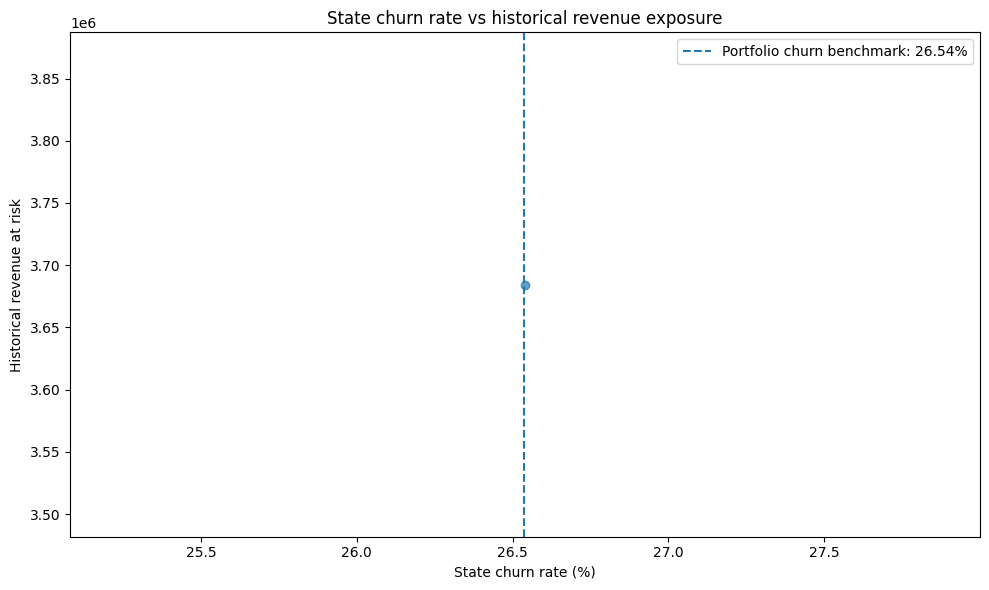

Result: Plotted state churn against historical revenue exposure with the portfolio churn benchmark shown as a reference line.


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(state_benchmark["churn_rate_pct"], state_benchmark["revenue_at_risk"], alpha=0.7)
ax.axvline(portfolio_churn, linestyle="--", label=f"Portfolio churn benchmark: {portfolio_churn:.2f}%")
ax.set_xlabel("State churn rate (%)")
ax.set_ylabel("Historical revenue at risk")
ax.set_title("State churn rate vs historical revenue exposure")
ax.legend()
plt.tight_layout()
plt.show()

print_result("Plotted state churn against historical revenue exposure with the portfolio churn benchmark shown as a reference line.")

### Result & conclusion

The chart helps distinguish percentage-based churn performance from financial exposure. A state can be above the churn benchmark without having the largest absolute revenue exposure.

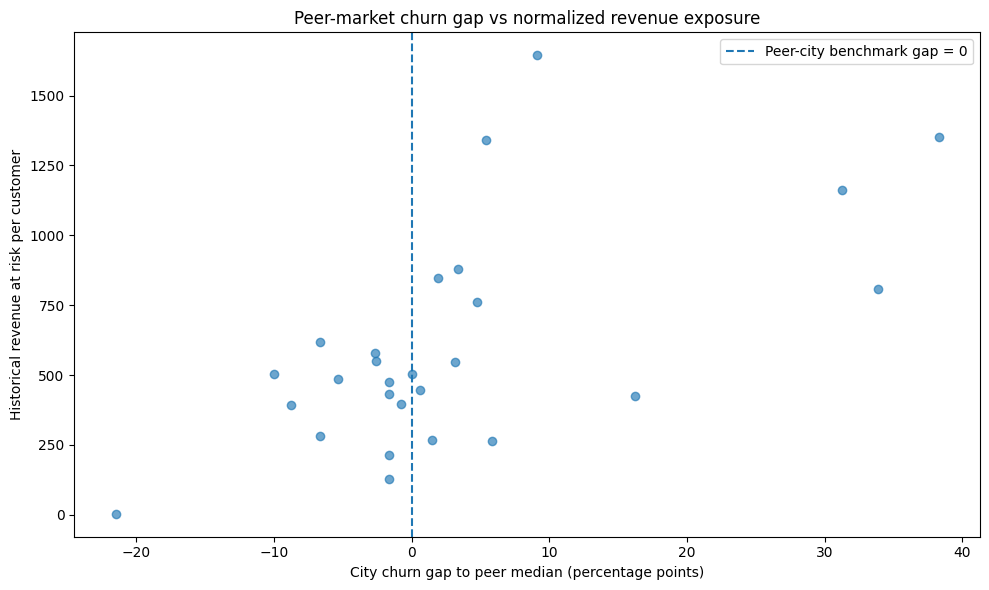

Result: Plotted city churn gaps against normalized historical revenue exposure to provide size-adjusted market context.


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(city_benchmark["churn_gap_to_peer_city_pp"], city_benchmark["revenue_at_risk_per_customer"], alpha=0.65)
ax.axvline(0, linestyle="--", label="Peer-city benchmark gap = 0")
ax.set_xlabel("City churn gap to peer median (percentage points)")
ax.set_ylabel("Historical revenue at risk per customer")
ax.set_title("Peer-market churn gap vs normalized revenue exposure")
ax.legend()
plt.tight_layout()
plt.show()

print_result("Plotted city churn gaps against normalized historical revenue exposure to provide size-adjusted market context.")

### Result & conclusion

The normalized view reduces the distortion caused by city size. It is still descriptive because both churn and revenue-at-risk are observed historical measures.

In [8]:
segment_benchmark.to_csv(OUTPUT_DIR / "segment_benchmark_gap.csv", index=False)
state_benchmark.to_csv(OUTPUT_DIR / "state_benchmark_gap.csv", index=False)
city_benchmark.to_csv(OUTPUT_DIR / "city_benchmark_gap.csv", index=False)

print_result("Saved segment, state, and city benchmark-gap outputs.")

Result: Saved segment, state, and city benchmark-gap outputs.


### Result & conclusion

The benchmark comparisons are now saved as portable datasets that can feed the management view and MySQL publishing notebooks.